In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
import joblib

In [2]:
Dataset= pd.read_csv("Mall_Customers.csv")

In [4]:
Dataset.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
Dataset.shape

(200, 5)

In [7]:
Dataset.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
Dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
Dataset.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
Dataset.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
Dataset.duplicated().sum()


np.int64(0)

In [12]:
Dataset.nunique()


CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

In [13]:
Dataset['Gender'].value_counts()


Gender
Female    112
Male       88
Name: count, dtype: int64

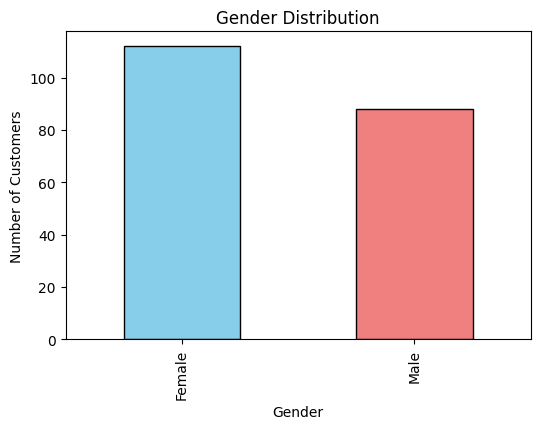

In [14]:
plt.figure(figsize=(6,4))

Dataset['Gender'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'lightcoral'],
    edgecolor='black'
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

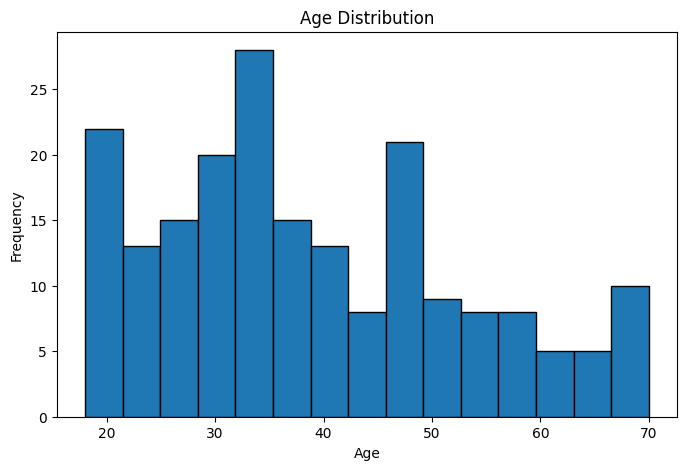

In [15]:
plt.figure(figsize=(8,5))

plt.hist(Dataset['Age'], bins=15, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

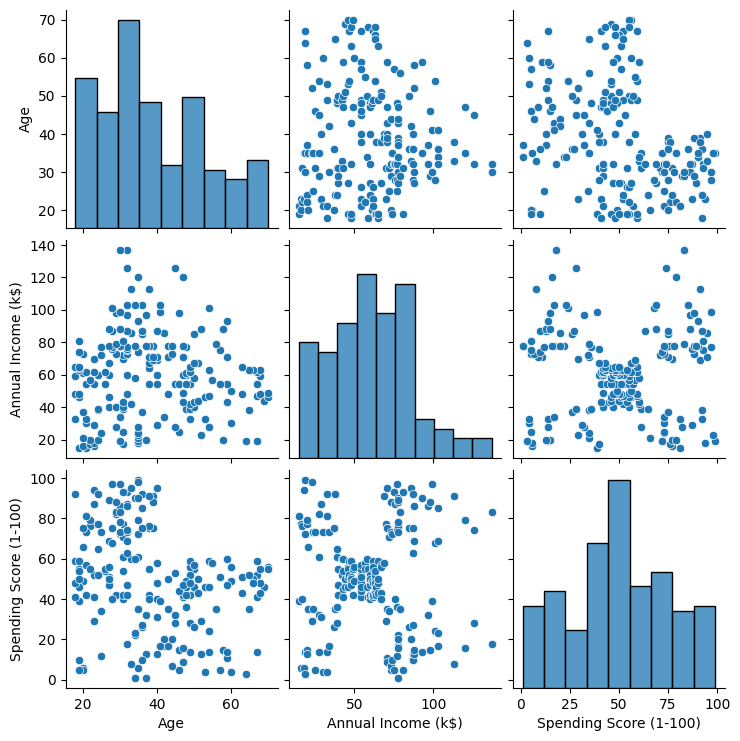

In [17]:
sns.pairplot(
    Dataset[['Age','Annual Income (k$)','Spending Score (1-100)']],
    diag_kind='hist'
)

plt.show()

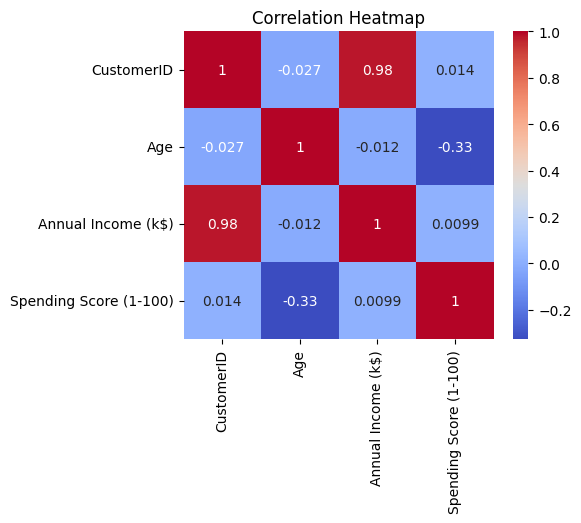

In [18]:
plt.figure(figsize=(5,4))

sns.heatmap(
    Dataset.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

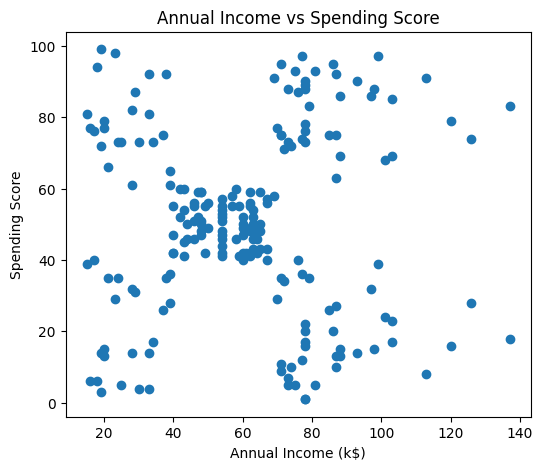

In [19]:
plt.figure(figsize=(6,5))

plt.scatter(
    Dataset['Annual Income (k$)'],
    Dataset['Spending Score (1-100)']
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

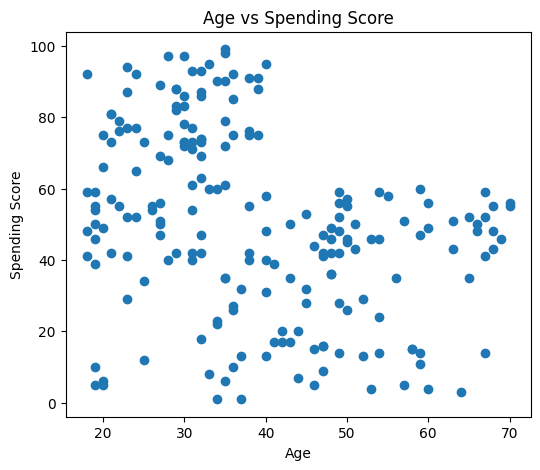

In [20]:
plt.figure(figsize=(6,5))

plt.scatter(
    Dataset['Age'],
    Dataset['Spending Score (1-100)']
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.show()


In [23]:
X = Dataset[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [24]:
X.shape


(200, 2)

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [27]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

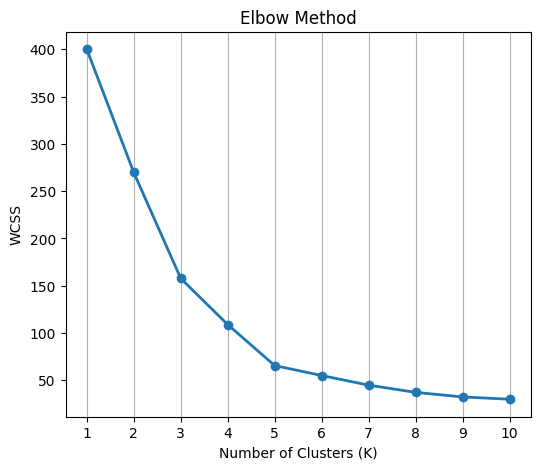

In [28]:
plt.figure(figsize=(6,5))

plt.plot(range(1,11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(range(1,11))
plt.grid(axis='x')

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

In [30]:
k_clusters = kmeans.fit_predict(X_scaled)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [31]:
Dataset['K_Cluster'] = k_clusters


In [32]:
Dataset.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [33]:
Dataset['K_Cluster'].value_counts().sort_index()


K_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [34]:
silhouette = silhouette_score(X_scaled, k_clusters)

print("Silhouette Score:", round(silhouette,3))

Silhouette Score: 0.555


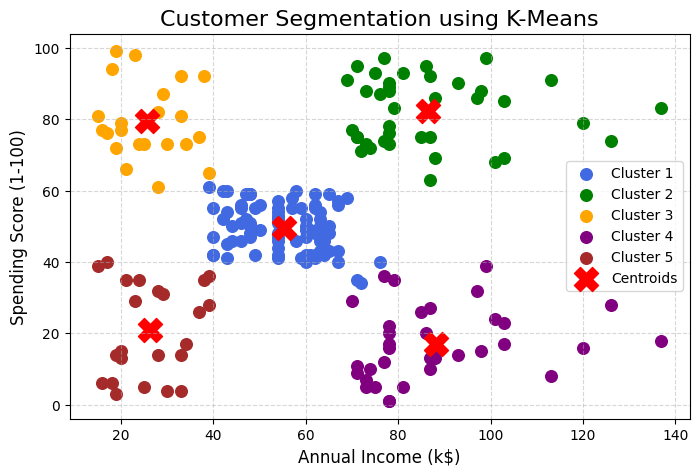

In [35]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,5))

colors = ['royalblue', 'green', 'orange', 'purple', 'brown']

for i in range(5):
    plt.scatter(
        Dataset[Dataset['K_Cluster'] == i]['Annual Income (k$)'],
        Dataset[Dataset['K_Cluster'] == i]['Spending Score (1-100)'],
        s=70,
        color=colors[i],
        label=f'Cluster {i+1}'
    )

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    color='red',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means", fontsize=16)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [36]:
cluster_summary = Dataset.groupby('K_Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
})

cluster_summary.rename(columns={
    'CustomerID': 'Number of Customers'
}, inplace=True)

cluster_summary.round(2)

,Annual Income (k$),Spending Score (1-100),Number of Customers
K_Cluster,,,
0,55.30,49.52,81
1,86.54,82.13,39
2,25.73,79.36,22
3,88.20,17.11,35
4,26.30,20.91,23


In [38]:
cluster_names = {
    0: 'Average Customers',
    1: 'High Income - High Spending',
    2: 'Low Income - High Spending',
    3: 'High Income - Low Spending',
    4: 'Low Income - Low Spending'
}

Dataset['K_Customer Segment'] = Dataset['K_Cluster'].map(cluster_names)

In [39]:
Dataset.head(10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster,K_Customer Segment
0,1,Male,19,15,39,4,Low Income - Low Spending
1,2,Male,21,15,81,2,Low Income - High Spending
2,3,Female,20,16,6,4,Low Income - Low Spending
3,4,Female,23,16,77,2,Low Income - High Spending
4,5,Female,31,17,40,4,Low Income - Low Spending
5,6,Female,22,17,76,2,Low Income - High Spending
6,7,Female,35,18,6,4,Low Income - Low Spending
7,8,Female,23,18,94,2,Low Income - High Spending
8,9,Male,64,19,3,4,Low Income - Low Spending
9,10,Female,30,19,72,2,Low Income - High Spending


In [40]:
recommendations = {
    'Average Customers': 'Maintain regular engagement through seasonal offers.',
    'High Income - High Spending': 'Reward with loyalty programs and exclusive memberships.',
    'Low Income - High Spending': 'Offer affordable deals and discount campaigns.',
    'High Income - Low Spending': 'Encourage spending with personalized premium offers.',
    'Low Income - Low Spending': 'Focus less on expensive marketing campaigns.'
}

business_summary = Dataset[['K_Customer Segment']].drop_duplicates().reset_index(drop=True)

business_summary['Recommendation'] = business_summary['K_Customer Segment'].map(recommendations)

business_summary

,K_Customer Segment,Recommendation
0,Low Income - Low Spending,Focus less on expensive marketing campaigns.
1,Low Income - High Spending,Offer affordable deals and discount campaigns.
2,Average Customers,Maintain regular engagement through seasonal o...
3,High Income - High Spending,Reward with loyalty programs and exclusive mem...
4,High Income - Low Spending,Encourage spending with personalized premium o...


In [41]:
linked = linkage(
    X_scaled,
    method='ward'
)

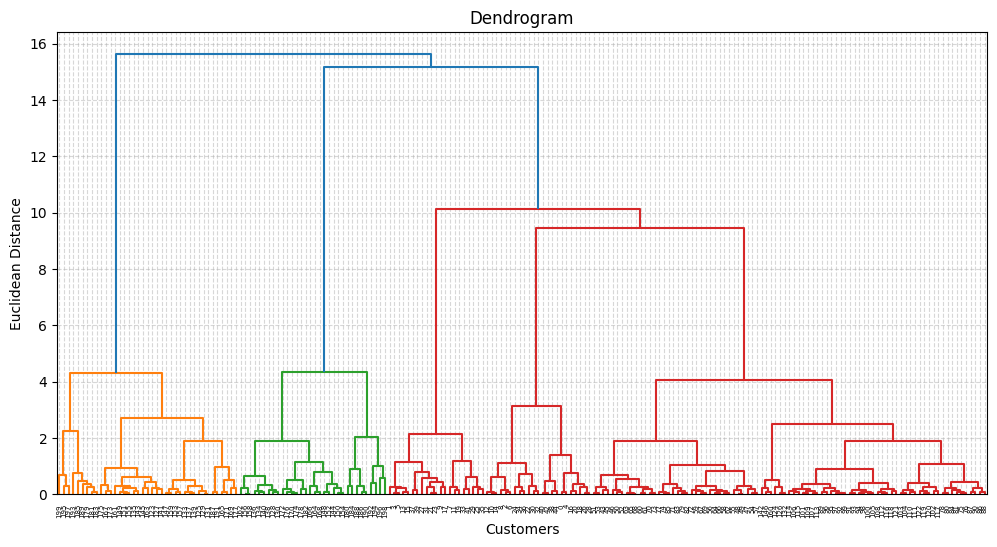

In [42]:
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [43]:
for k in [3, 4, 5]:
    hc = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )

    labels = hc.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f"k = {k} --> Silhouette Score = {score:.3f}")

k = 3 --> Silhouette Score = 0.461
k = 4 --> Silhouette Score = 0.493
k = 5 --> Silhouette Score = 0.554


In [44]:
hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

In [45]:
hc_clusters = hc.fit_predict(X_scaled)


In [46]:
Dataset['HC_Cluster'] = hc_clusters


In [47]:
Dataset.head(5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster,K_Customer Segment,HC_Cluster
0,1,Male,19,15,39,4,Low Income - Low Spending,4
1,2,Male,21,15,81,2,Low Income - High Spending,3
2,3,Female,20,16,6,4,Low Income - Low Spending,4
3,4,Female,23,16,77,2,Low Income - High Spending,3
4,5,Female,31,17,40,4,Low Income - Low Spending,4


In [48]:
Dataset['HC_Cluster'].value_counts().sort_index()


HC_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64

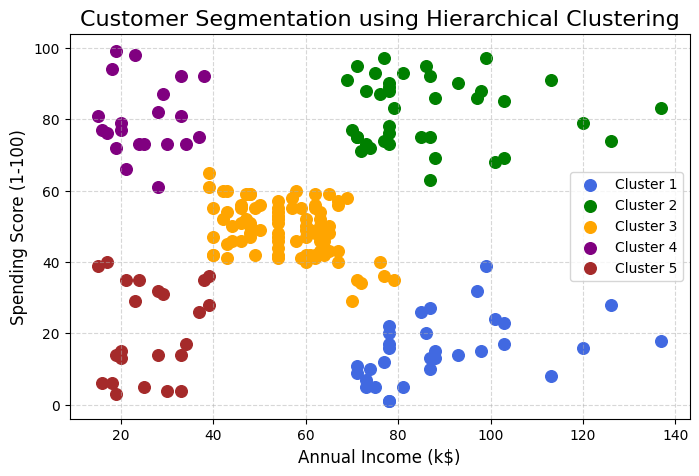

In [49]:
plt.figure(figsize=(8,5))

colors = ['royalblue', 'green', 'orange', 'purple', 'brown']

for i in range(5):
    plt.scatter(
        Dataset[Dataset['HC_Cluster'] == i]['Annual Income (k$)'],
        Dataset[Dataset['HC_Cluster'] == i]['Spending Score (1-100)'],
        s=70,
        color=colors[i],
        label=f'Cluster {i+1}'
    )

plt.title("Customer Segmentation using Hierarchical Clustering", fontsize=16)

plt.xlabel("Annual Income (k$)", fontsize=12)

plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

In [50]:
hc_summary = Dataset.groupby('HC_Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
})

hc_summary.rename(columns={
    'CustomerID': 'Number of Customers'
}, inplace=True)

hc_summary.round(2)

,Annual Income (k$),Spending Score (1-100),Number of Customers
HC_Cluster,,,
0,89.41,15.59,32
1,86.54,82.13,39
2,55.81,49.13,85
3,25.10,80.05,21
4,26.30,20.91,23


In [51]:
hc_cluster_names = {
    0: 'High Income - Low Spending',
    1: 'High Income - High Spending',
    2: 'Average Customers',
    3: 'Low Income - High Spending',
    4: 'Low Income - Low Spending'
}

Dataset['HC_Customer Segment'] = Dataset['HC_Cluster'].map(hc_cluster_names)

In [52]:
Dataset.head(10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster,K_Customer Segment,HC_Cluster,HC_Customer Segment
0,1,Male,19,15,39,4,Low Income - Low Spending,4,Low Income - Low Spending
1,2,Male,21,15,81,2,Low Income - High Spending,3,Low Income - High Spending
2,3,Female,20,16,6,4,Low Income - Low Spending,4,Low Income - Low Spending
3,4,Female,23,16,77,2,Low Income - High Spending,3,Low Income - High Spending
4,5,Female,31,17,40,4,Low Income - Low Spending,4,Low Income - Low Spending
5,6,Female,22,17,76,2,Low Income - High Spending,3,Low Income - High Spending
6,7,Female,35,18,6,4,Low Income - Low Spending,4,Low Income - Low Spending
7,8,Female,23,18,94,2,Low Income - High Spending,3,Low Income - High Spending
8,9,Male,64,19,3,4,Low Income - Low Spending,4,Low Income - Low Spending
9,10,Female,30,19,72,2,Low Income - High Spending,3,Low Income - High Spending


In [54]:
hc_recommendations = {
    'Average Customers': 'Maintain regular engagement through seasonal offers.',
    'High Income - High Spending': 'Reward with loyalty programs and exclusive memberships.',
    'Low Income - High Spending': 'Offer affordable deals and discount campaigns.',
    'High Income - Low Spending': 'Encourage spending with personalized premium offers.',
    'Low Income - Low Spending': 'Focus less on expensive marketing campaigns.'
}

hc_business_summary = Dataset[['HC_Customer Segment']].drop_duplicates().reset_index(drop=True)

hc_business_summary['Recommendation'] = hc_business_summary['HC_Customer Segment'].map(hc_recommendations)

hc_business_summary

,HC_Customer Segment,Recommendation
0,Low Income - Low Spending,Focus less on expensive marketing campaigns.
1,Low Income - High Spending,Offer affordable deals and discount campaigns.
2,Average Customers,Maintain regular engagement through seasonal o...
3,High Income - High Spending,Reward with loyalty programs and exclusive mem...
4,High Income - Low Spending,Encourage spending with personalized premium o...


In [55]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

In [56]:
db_clusters = dbscan.fit_predict(X_scaled)


In [57]:
np.unique(db_clusters)


array([-1,  0,  1,  2,  3,  4,  5,  6])

In [58]:
Dataset['DBSCAN_Cluster'] = db_clusters

Dataset.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster,K_Customer Segment,HC_Cluster,HC_Customer Segment,DBSCAN_Cluster
0,1,Male,19,15,39,4,Low Income - Low Spending,4,Low Income - Low Spending,2
1,2,Male,21,15,81,2,Low Income - High Spending,3,Low Income - High Spending,0
2,3,Female,20,16,6,4,Low Income - Low Spending,4,Low Income - Low Spending,1
3,4,Female,23,16,77,2,Low Income - High Spending,3,Low Income - High Spending,0
4,5,Female,31,17,40,4,Low Income - Low Spending,4,Low Income - Low Spending,2


In [59]:
Dataset['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1    35
 0    12
 1     5
 2     7
 3    88
 4    30
 5    14
 6     9
Name: count, dtype: int64

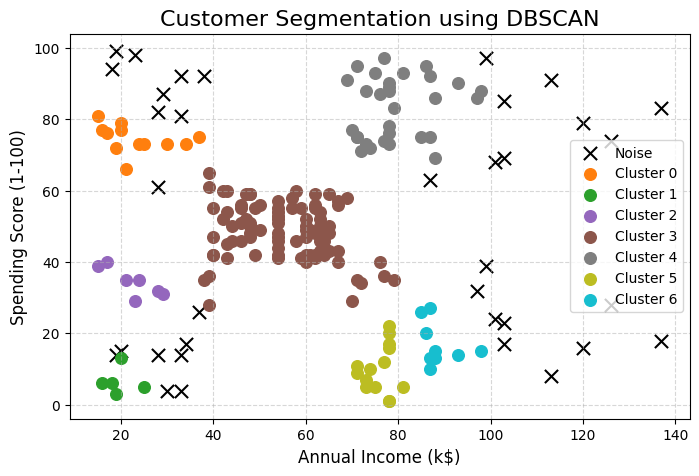

In [60]:
plt.figure(figsize=(8,5))

unique_clusters = np.unique(db_clusters)

colors = plt.cm.tab10(np.linspace(0,1,len(unique_clusters)))

for cluster, color in zip(unique_clusters, colors):

    if cluster == -1:
        plt.scatter(
            Dataset[Dataset['DBSCAN_Cluster']==cluster]['Annual Income (k$)'],
            Dataset[Dataset['DBSCAN_Cluster']==cluster]['Spending Score (1-100)'],
            color='black',
            marker='x',
            s=90,
            label='Noise'
        )

    else:
        plt.scatter(
            Dataset[Dataset['DBSCAN_Cluster']==cluster]['Annual Income (k$)'],
            Dataset[Dataset['DBSCAN_Cluster']==cluster]['Spending Score (1-100)'],
            color=color,
            s=70,
            label=f'Cluster {cluster}'
        )

plt.title("Customer Segmentation using DBSCAN", fontsize=16)

plt.xlabel("Annual Income (k$)", fontsize=12)

plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

In [61]:
mask = db_clusters != -1

X_dbscan = X_scaled[mask]

labels_dbscan = db_clusters[mask]

score = silhouette_score(X_dbscan, labels_dbscan)

print("DBSCAN Silhouette Score =", round(score,3))

DBSCAN Silhouette Score = 0.524


In [62]:
dbscan_summary = Dataset[Dataset['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
})

dbscan_summary.rename(columns={
    'CustomerID': 'Number of Customers'
}, inplace=True)

dbscan_summary.round(2)

,Annual Income (k$),Spending Score (1-100),Number of Customers
DBSCAN_Cluster,,,
0,23.17,74.58,12
1,19.60,6.60,5
2,22.43,34.43,7
3,55.23,48.58,88
4,79.53,83.13,30
5,75.93,10.07,14
6,88.78,17.00,9


In [63]:
dbscan_cluster_names = {
    0: 'Low Income - High Spending',
    1: 'Low Income - Low Spending',
    2: 'Low Income - Average Spending',
    3: 'Average Customers',
    4: 'High Income - High Spending',
    5: 'High Income - Low Spending',
    6: 'Very High Income - Low Spending'
}

Dataset['DBSCAN Customer Segment'] = Dataset['DBSCAN_Cluster'].map(dbscan_cluster_names)

Dataset[['Annual Income (k$)',
         'Spending Score (1-100)',
         'DBSCAN Customer Segment']].head(10)

,Annual Income (k$),Spending Score (1-100),DBSCAN Customer Segment
0,15,39,Low Income - Average Spending
1,15,81,Low Income - High Spending
2,16,6,Low Income - Low Spending
3,16,77,Low Income - High Spending
4,17,40,Low Income - Average Spending
5,17,76,Low Income - High Spending
6,18,6,Low Income - Low Spending
7,18,94,NaN
8,19,3,Low Income - Low Spending
9,19,72,Low Income - High Spending


In [64]:
dbscan_recommendations = {
    'Low Income - High Spending':
        'Offer affordable deals and discount campaigns.',

    'Low Income - Low Spending':
        'Focus less on expensive marketing campaigns.',

    'Low Income - Average Spending':
        'Increase engagement through budget-friendly promotions.',

    'Average Customers':
        'Maintain regular engagement through seasonal offers.',

    'High Income - High Spending':
        'Reward with loyalty programs and exclusive memberships.',

    'High Income - Low Spending':
        'Encourage spending with personalized premium offers.',

    'Very High Income - Low Spending':
        'Target with luxury products and exclusive premium experiences.'
}

dbscan_business_summary = Dataset[['DBSCAN Customer Segment']].drop_duplicates().reset_index(drop=True)

dbscan_business_summary['Recommendation'] = dbscan_business_summary['DBSCAN Customer Segment'].map(dbscan_recommendations)

dbscan_business_summary

,DBSCAN Customer Segment,Recommendation
0,Low Income - Average Spending,Increase engagement through budget-friendly pr...
1,Low Income - High Spending,Offer affordable deals and discount campaigns.
2,Low Income - Low Spending,Focus less on expensive marketing campaigns.
3,NaN,NaN
4,Average Customers,Maintain regular engagement through seasonal o...
5,High Income - High Spending,Reward with loyalty programs and exclusive mem...
6,High Income - Low Spending,Encourage spending with personalized premium o...
7,Very High Income - Low Spending,Target with luxury products and exclusive prem...


In [65]:
gmm = GaussianMixture(
    n_components=5,
    random_state=42
)

In [66]:
gmm_clusters = gmm.fit_predict(X_scaled)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [67]:
np.unique(gmm_clusters)


array([0, 1, 2, 3, 4])

In [68]:
Dataset['GMM_Cluster'] = gmm_clusters


In [69]:
Dataset.head(5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster,K_Customer Segment,HC_Cluster,HC_Customer Segment,DBSCAN_Cluster,DBSCAN Customer Segment,GMM_Cluster
0,1,Male,19,15,39,4,Low Income - Low Spending,4,Low Income - Low Spending,2,Low Income - Average Spending,4
1,2,Male,21,15,81,2,Low Income - High Spending,3,Low Income - High Spending,0,Low Income - High Spending,2
2,3,Female,20,16,6,4,Low Income - Low Spending,4,Low Income - Low Spending,1,Low Income - Low Spending,4
3,4,Female,23,16,77,2,Low Income - High Spending,3,Low Income - High Spending,0,Low Income - High Spending,2
4,5,Female,31,17,40,4,Low Income - Low Spending,4,Low Income - Low Spending,2,Low Income - Average Spending,4


In [70]:
Dataset['GMM_Cluster'].value_counts().sort_index()


GMM_Cluster
0    84
1    39
2    21
3    33
4    23
Name: count, dtype: int64

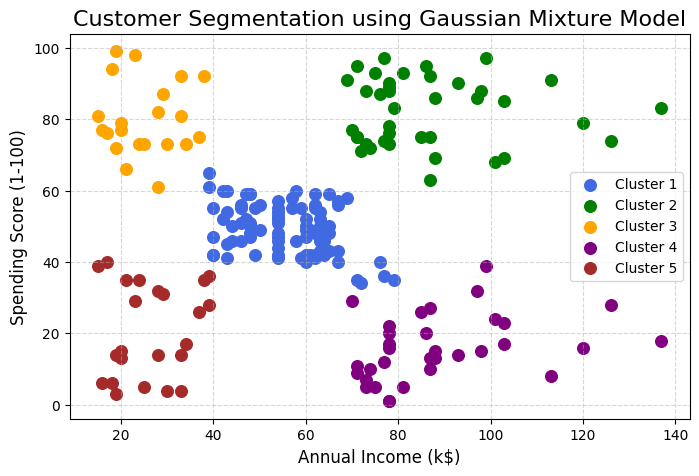

In [71]:
plt.figure(figsize=(8,5))

colors = ['royalblue', 'green', 'orange', 'purple', 'brown']

for i in range(5):
    plt.scatter(
        Dataset[Dataset['GMM_Cluster'] == i]['Annual Income (k$)'],
        Dataset[Dataset['GMM_Cluster'] == i]['Spending Score (1-100)'],
        s=70,
        color=colors[i],
        label=f'Cluster {i+1}'
    )

plt.title("Customer Segmentation using Gaussian Mixture Model", fontsize=16)

plt.xlabel("Annual Income (k$)", fontsize=12)

plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

In [72]:
gmm_score = silhouette_score(X_scaled, gmm_clusters)

print("Silhouette Score:", round(gmm_score, 3))

Silhouette Score: 0.554


In [73]:
gmm_summary = Dataset.groupby('GMM_Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
})

gmm_summary.rename(columns={
    'CustomerID': 'Number of Customers'
}, inplace=True)

gmm_summary.round(2)

,Annual Income (k$),Spending Score (1-100),Number of Customers
GMM_Cluster,,,
0,55.64,49.37,84
1,86.54,82.13,39
2,25.10,80.05,21
3,88.82,16.00,33
4,26.30,20.91,23


In [74]:
gmm_cluster_names = {
    0: 'Average Customers',
    1: 'High Income - High Spending',
    2: 'Low Income - High Spending',
    3: 'High Income - Low Spending',
    4: 'Low Income - Low Spending'
}

Dataset['GMM_Customer_Segment'] = Dataset['GMM_Cluster'].map(gmm_cluster_names)

Dataset.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),K_Cluster,K_Customer Segment,HC_Cluster,HC_Customer Segment,DBSCAN_Cluster,DBSCAN Customer Segment,GMM_Cluster,GMM_Customer_Segment
0,1,Male,19,15,39,4,Low Income - Low Spending,4,Low Income - Low Spending,2,Low Income - Average Spending,4,Low Income - Low Spending
1,2,Male,21,15,81,2,Low Income - High Spending,3,Low Income - High Spending,0,Low Income - High Spending,2,Low Income - High Spending
2,3,Female,20,16,6,4,Low Income - Low Spending,4,Low Income - Low Spending,1,Low Income - Low Spending,4,Low Income - Low Spending
3,4,Female,23,16,77,2,Low Income - High Spending,3,Low Income - High Spending,0,Low Income - High Spending,2,Low Income - High Spending
4,5,Female,31,17,40,4,Low Income - Low Spending,4,Low Income - Low Spending,2,Low Income - Average Spending,4,Low Income - Low Spending
5,6,Female,22,17,76,2,Low Income - High Spending,3,Low Income - High Spending,0,Low Income - High Spending,2,Low Income - High Spending
6,7,Female,35,18,6,4,Low Income - Low Spending,4,Low Income - Low Spending,1,Low Income - Low Spending,4,Low Income - Low Spending
7,8,Female,23,18,94,2,Low Income - High Spending,3,Low Income - High Spending,-1,NaN,2,Low Income - High Spending
8,9,Male,64,19,3,4,Low Income - Low Spending,4,Low Income - Low Spending,1,Low Income - Low Spending,4,Low Income - Low Spending
9,10,Female,30,19,72,2,Low Income - High Spending,3,Low Income - High Spending,0,Low Income - High Spending,2,Low Income - High Spending


In [75]:
recommendations = {
    'Average Customers': 'Maintain regular engagement through seasonal offers.',
    'High Income - High Spending': 'Reward with loyalty programs and exclusive memberships.',
    'Low Income - High Spending': 'Offer affordable deals and discount campaigns.',
    'High Income - Low Spending': 'Encourage spending with personalized premium offers.',
    'Low Income - Low Spending': 'Focus less on expensive marketing campaigns.'
}

gmm_business_summary = Dataset[['GMM_Customer_Segment']].drop_duplicates().reset_index(drop=True)

gmm_business_summary['Recommendation'] = gmm_business_summary['GMM_Customer_Segment'].map(recommendations)

gmm_business_summary

,GMM_Customer_Segment,Recommendation
0,Low Income - Low Spending,Focus less on expensive marketing campaigns.
1,Low Income - High Spending,Offer affordable deals and discount campaigns.
2,Average Customers,Maintain regular engagement through seasonal o...
3,High Income - High Spending,Reward with loyalty programs and exclusive mem...
4,High Income - Low Spending,Encourage spending with personalized premium o...


In [76]:
comparison = {
    'Algorithm': [
        'K-Means',
        'Hierarchical Clustering',
        'DBSCAN',
        'Gaussian Mixture Model'
    ],

    'Number of Clusters': [
        5,
        5,
        7,      
        5
    ],

    'Silhouette Score': [
        0.555,
        0.554,
        0.524,
        0.554
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Algorithm,Number of Clusters,Silhouette Score
0,K-Means,5,0.555
1,Hierarchical Clustering,5,0.554
2,DBSCAN,7,0.524
3,Gaussian Mixture Model,5,0.554


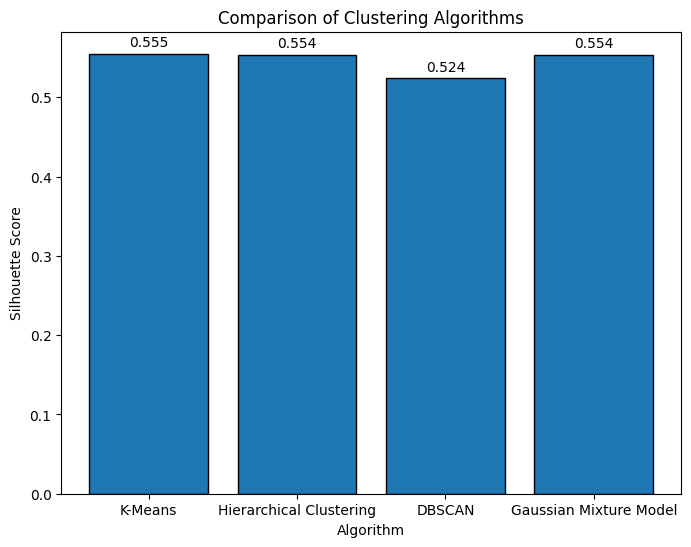

In [77]:
plt.figure(figsize=(8,6))

bars = plt.bar(
    comparison_df['Algorithm'],
    comparison_df['Silhouette Score'],
    edgecolor='black'
)

plt.bar_label(bars, fmt='%.3f', padding=3)

plt.title("Comparison of Clustering Algorithms")

plt.xlabel("Algorithm")

plt.ylabel("Silhouette Score")

plt.show()

In [78]:
best_algorithm = comparison_df.loc[
    comparison_df['Silhouette Score'].idxmax()
]

best_algorithm

Algorithm             K-Means
Number of Clusters          5
Silhouette Score        0.555
Name: 0, dtype: object

In [80]:
import os
import joblib
joblib.dump(kmeans, 'best_kmeans_model.pkl')

if os.path.exists('best_kmeans_model.pkl'):
    print("Best K-Means model saved successfully.")
else:
    print("Model could not be saved.")

Best K-Means model saved successfully.


In [81]:
joblib.dump(scaler, 'scaler.pkl')

if os.path.exists('scaler.pkl'):
    print("Scaler saved successfully.")
else:
    print("Scaler could not be saved.")

Scaler saved successfully.


In [82]:
best_model = joblib.load('best_kmeans_model.pkl')

saved_scaler = joblib.load('scaler.pkl')

In [83]:
new_customer = pd.DataFrame({
    'Annual Income (k$)': [70],
    'Spending Score (1-100)': [80]
})

In [86]:
new_customer_scaled = saved_scaler.transform(new_customer)

In [87]:
predicted_cluster = best_model.predict(new_customer_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 1


In [88]:
cluster_names = {
    0: 'Average Customers',
    1: 'High Income - High Spending',
    2: 'Low Income - High Spending',
    3: 'High Income - Low Spending',
    4: 'Low Income - Low Spending'
}

print("Customer Segment:", cluster_names[predicted_cluster[0]])

Customer Segment: High Income - High Spending


In [89]:
recommendations = {
    'Average Customers': 'Maintain regular engagement through seasonal offers.',
    'High Income - High Spending': 'Reward with loyalty programs and exclusive memberships.',
    'Low Income - High Spending': 'Offer affordable deals and discount campaigns.',
    'High Income - Low Spending': 'Encourage spending with personalized premium offers.',
    'Low Income - Low Spending': 'Focus less on expensive marketing campaigns.'
}

print("Recommendation:")
print(recommendations[cluster_names[predicted_cluster[0]]])

Recommendation:
Reward with loyalty programs and exclusive memberships.
